In [1]:
pip install peft

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 320.7/320.7 kB 6.0 MB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install optuna

Note: you may need to restart the kernel to use updated packages.


In [30]:
import matplotlib.pyplot as plt
from datasets import load_dataset
from transformers import T5Tokenizer, T5ForConditionalGeneration
from torch.utils.data import DataLoader
import torch
from torch.utils.data import Dataset
from transformers import AdamW
from tqdm import tqdm
from sklearn.metrics import accuracy_score
from transformers import AutoTokenizer
from peft import get_peft_model, LoraConfig
import optuna


### Load WiC dataset from SuperGLUE

In [31]:

dataset = load_dataset("super_glue", "wic")

def preprocess_wic(example):
    word = example["word"]
    sentence1 = example["sentence1"]
    sentence2 = example["sentence2"]
    label = example["label"]  

    inputs = f"Sentence 1: {sentence1} Sentence 2: {sentence2} Word: {word}"
    targets = "Yes" if label == 1 else "No"
    return {"input_text": inputs, "target_text": targets}

dataset = dataset.map(preprocess_wic)


### Load the T5 tokenizer and model

In [32]:

model_name = "t5-base"  
tokenizer = T5Tokenizer.from_pretrained(model_name)
model = T5ForConditionalGeneration.from_pretrained(model_name)

lora_config = LoraConfig(
    r=8,  # Rank of the adapter matrices
    lora_alpha=16,  # Scaling factor for LoRA
    target_modules=["q", "k", "v","r"],  # Modules to apply LoRA to (attention layers)
    lora_dropout=0.45,  # Dropout for LoRA layers
)

model = get_peft_model(model, lora_config)

### Tokenize the dataset after preprocessing

In [33]:
def tokenize_data(example):
    input_encodings = tokenizer(
        example["input_text"],
        max_length=128,
        padding="max_length",
        truncation=True,
    )
    target_encodings = tokenizer(
        example["target_text"],
        max_length=10,
        padding="max_length",
        truncation=True,
    )
    return {
        "input_ids": input_encodings["input_ids"],
        "attention_mask": input_encodings["attention_mask"],
        "labels": target_encodings["input_ids"],
    }


tokenized_datasets = dataset.map(tokenize_data, batched=True)


In [34]:

train_dataset = tokenized_datasets["train"].with_format("torch")
valid_dataset = tokenized_datasets["validation"].with_format("torch")
test_dataset = tokenized_datasets["test"].with_format("torch")


train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=16)
test_loader = DataLoader(test_dataset, batch_size=16)

In [27]:
def set_model_dropout(model, dropout_rate):
    """
    Recursively sets the dropout rate for all Dropout layers in the model.
    """
    for module in model.modules():
        if isinstance(module, torch.nn.Dropout):
            module.p = dropout_rate


def objective(trial):
    # Suggest hyperparameters
    learning_rate = trial.suggest_loguniform("lr", 1e-5, 1e-3)
    batch_size = trial.suggest_categorical("batch_size", [8, 16, 32])
    dropout = trial.suggest_uniform("dropout", 0.1, 0.5)  # Dropout rate

    # DataLoader
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    valid_loader = DataLoader(valid_dataset, batch_size=batch_size)

    # Optimizer
    optimizer = AdamW(model.parameters(), lr=learning_rate)

    # Adjust dropout rate in the model
    set_model_dropout(model, dropout)

    # Training
    num_epochs = 5
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    best_val_accuracy = 0

    for epoch in range(num_epochs):
        model.train()
        for batch in tqdm(train_loader):
            optimizer.zero_grad()

            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            # For T5, the labels should be passed as decoder_input_ids
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            loss.backward()
            optimizer.step()

        # Validation
        model.eval()
        correct_preds = 0
        total_preds = 0

        with torch.no_grad():
            for batch in valid_loader:
                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                labels = batch["labels"].to(device)

                # During validation, we need to pass decoder_input_ids for inference
                decoder_input_ids = labels  # Or use a special start token, if necessary

                outputs = model(input_ids=input_ids, attention_mask=attention_mask, decoder_input_ids=decoder_input_ids)
                predictions = torch.argmax(outputs.logits, dim=-1)

                correct_preds += (predictions == labels).sum().item()
                total_preds += labels.size(0)

        val_accuracy = correct_preds / total_preds
        best_val_accuracy = max(best_val_accuracy, val_accuracy)

        trial.report(val_accuracy, epoch)

        if trial.should_prune():
            raise optuna.TrialPruned()

    return best_val_accuracy


# Optuna study
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=10)


[I 2024-11-23 12:17:21,993] A new study created in memory with name: no-name-93782fe9-6395-4ce8-bb7d-8907523da373
/tmp/ipykernel_30/3365311931.py:12: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform("lr", 1e-5, 1e-3)
/tmp/ipykernel_30/3365311931.py:14: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  dropout = trial.suggest_uniform("dropout", 0.1, 0.5)  # Dropout rate
100%|██████████| 340/340 [02:00<00:00,  2.83it/s]
[I 2024-11-23 12:27:56,879] Trial 0 finished with value: 8.0 and parameters: {'lr': 9.762477675627743e-05, 'batch_size': 16, 'dropout': 0.4501816446303697}. Best is trial 0 with value: 8.0.
100%|██████████| 340/340 [02:00<00:00,  2.83it/s]


In [29]:
print("Best hyperparameters:", study.best_params)

Best hyperparameters: {'lr': 9.762477675627743e-05, 'batch_size': 16, 'dropout': 0.4501816446303697}


In [ ]:
best_params = study.best_params

learning_rate = best_params['learning_rate']
batch_size = best_params['batch_size']
dropout = best_params['dropout']


In [36]:
class CustomTestDataset(Dataset):
    def __init__(self, input_file, label_file, tokenizer, max_length=128):
        # Load input data
        with open(input_file, "r") as f:
            self.inputs = [line.strip() for line in f.readlines()]

        # Load labels
        with open(label_file, "r") as f:
            self.labels = [1 if line.strip() == "T" else 0 for line in f.readlines()]

        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.inputs)

    def __getitem__(self, idx):
        # Extract input and label for the current index
        input_text = self.inputs[idx]
        label = self.labels[idx]

        # Tokenize the input text
        encodings = self.tokenizer(
            input_text,
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )

        return {
            "input_ids": encodings["input_ids"].squeeze(0),  # Remove batch dimension
            "attention_mask": encodings["attention_mask"].squeeze(0),
            "labels": torch.tensor(label, dtype=torch.long),
        }


In [38]:
# Initialize tokenizer
tokenizer = AutoTokenizer.from_pretrained("t5-base")

# Create the test dataset
test_dataset = CustomTestDataset(
    input_file="/kaggle/input/wic-dataset-test/test/formatted_data.txt",
    label_file="/kaggle/input/wic-dataset-test/test/test.gold.txt",
    tokenizer=tokenizer
)

# Create the DataLoader for batching
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# Inspect a batch
for batch in test_loader:
    print(batch)
    break


{'input_ids': tensor([[7142,  536,   10,  ...,    0,    0,    0],
        [7142,  536,   10,  ...,    0,    0,    0],
        [7142,  536,   10,  ...,    0,    0,    0],
        ...,
        [7142,  536,   10,  ...,    0,    0,    0],
        [7142,  536,   10,  ...,    0,    0,    0],
        [7142,  536,   10,  ...,    0,    0,    0]]), 'attention_mask': tensor([[1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        ...,
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0]]), 'labels': tensor([1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0])}


In [39]:
# Optimizer
optimizer = AdamW(model.parameters(), lr=9.762477675627743e-05)
num_epochs = 20

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
model.to(device)


cuda


PeftModel(
  (base_model): LoraModel(
    (model): T5ForConditionalGeneration(
      (shared): Embedding(32128, 768)
      (encoder): T5Stack(
        (embed_tokens): Embedding(32128, 768)
        (block): ModuleList(
          (0): T5Block(
            (layer): ModuleList(
              (0): T5LayerSelfAttention(
                (SelfAttention): T5Attention(
                  (q): lora.Linear(
                    (base_layer): Linear(in_features=768, out_features=768, bias=False)
                    (lora_dropout): ModuleDict(
                      (default): Dropout(p=0.45, inplace=False)
                    )
                    (lora_A): ModuleDict(
                      (default): Linear(in_features=768, out_features=8, bias=False)
                    )
                    (lora_B): ModuleDict(
                      (default): Linear(in_features=8, out_features=768, bias=False)
                    )
                    (lora_embedding_A): ParameterDict()
                    (lora_

### Training

In [40]:

train_losses = []
train_accuracies = []  
val_losses = []  
val_accuracies = [] 

patience_epochs = 3  
best_val_loss = float('inf')  
epochs_without_improvement = 0 
actual_epochs=0

for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    correct_train_preds = 0  
    total_train_tokens = 0  
    actual_epochs+=1

    for batch in tqdm(train_loader):
        optimizer.zero_grad()

      
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

      
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        train_loss += loss.item()

       
        logits = outputs.logits
        predicted_labels = torch.argmax(logits, dim=-1)  

      
        predicted_labels_flat = predicted_labels.view(-1)
        labels_flat = labels.view(-1)

        mask = labels_flat != -100
        correct_train_preds += (predicted_labels_flat[mask] == labels_flat[mask]).sum().item()
        total_train_tokens += mask.sum().item()

       
        loss.backward()
        optimizer.step()

  
    avg_train_loss = train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
 
    train_accuracy = correct_train_preds / total_train_tokens
    train_accuracies.append(train_accuracy)
    
    print(f"Epoch {epoch + 1}, Training Loss: {avg_train_loss:.4f}, Training Accuracy: {train_accuracy * 100:.2f}%")

   
    model.eval()
    val_loss = 0
    correct_val_preds = 0
    total_val_tokens = 0  
    predictions = []
    references = []

    for batch in tqdm(valid_loader):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        with torch.no_grad():
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)

        loss = outputs.loss
        val_loss += loss.item()

        logits = outputs.logits
        predicted_labels = torch.argmax(logits, dim=-1)  

        # Flatten tensors to compare predictions and labels token-wise
        predicted_labels_flat = predicted_labels.view(-1)
        labels_flat = labels.view(-1)

        # Mask padding tokens if necessary
        mask = labels_flat != -100
        correct_val_preds += (predicted_labels_flat[mask] == labels_flat[mask]).sum().item()
        total_val_tokens += mask.sum().item()

        decoded_preds = tokenizer.batch_decode(predicted_labels, skip_special_tokens=True)
        decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

        predictions.extend(decoded_preds)
        references.extend(decoded_labels)

   
    avg_val_loss = val_loss / len(valid_loader)
    val_losses.append(avg_val_loss)

   
    val_accuracy = correct_val_preds / total_val_tokens  
    val_accuracies.append(val_accuracy)
    
    print(f"Epoch {epoch + 1}, Validation Loss: {avg_val_loss:.4f}, Validation Accuracy: {val_accuracy * 100:.2f}%")

    
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_without_improvement = 0
        
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"Validation loss improved. Saving model to 'best_model.pth'")
    else:
        epochs_without_improvement += 1

    
    if epochs_without_improvement >= patience_epochs:
        print(f"Early stopping. Validation loss did not improve for {patience_epochs} epochs.")
        break


100%|██████████| 340/340 [02:01<00:00,  2.80it/s]


Epoch 1, Training Loss: 3.8062, Training Accuracy: 62.57%


100%|██████████| 40/40 [00:06<00:00,  5.90it/s]


Epoch 1, Validation Loss: 0.1292, Validation Accuracy: 94.94%
Validation loss improved. Saving model to 'best_model.pth'


100%|██████████| 340/340 [02:01<00:00,  2.80it/s]


...

Epoch 10, Validation Loss: 0.0706, Validation Accuracy: 95.34%


100%|██████████| 340/340 [02:01<00:00,  2.80it/s]


Epoch 11, Training Loss: 0.0703, Training Accuracy: 95.81%


100%|██████████| 40/40 [00:06<00:00,  5.99it/s]

Epoch 11, Validation Loss: 0.0772, Validation Accuracy: 95.25%
Early stopping. Validation loss did not improve for 3 epochs.


### Plotting for visualisation

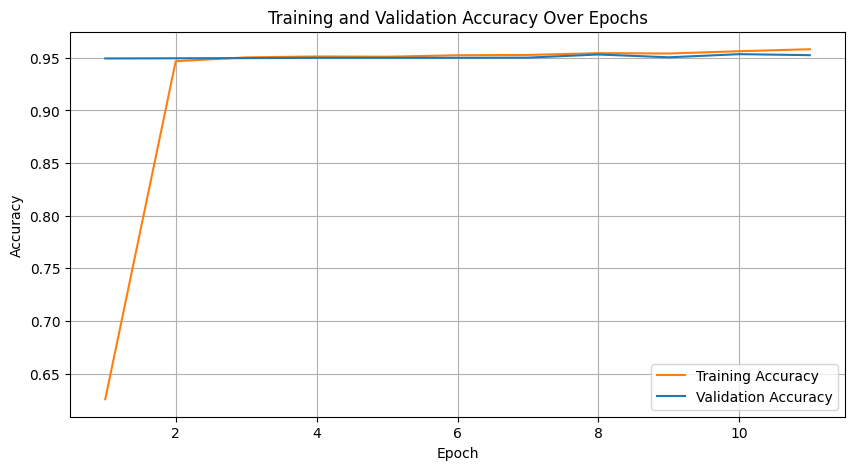

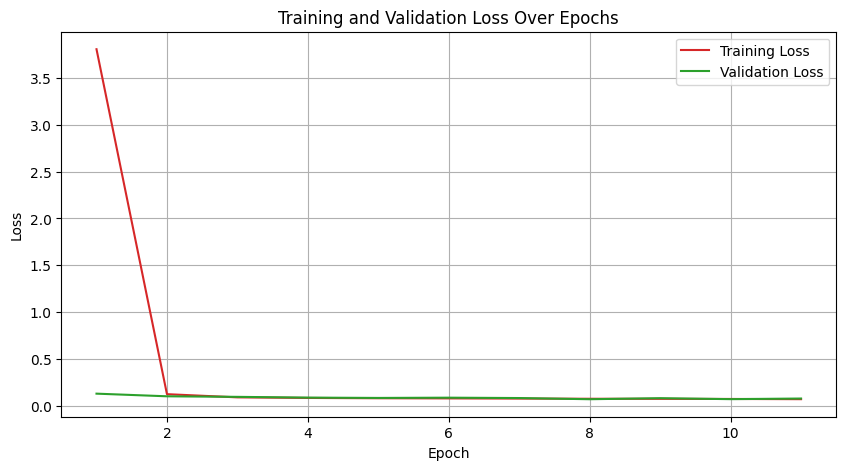

In [41]:


plt.figure(figsize=(10, 5))
plt.plot(range(1, actual_epochs + 1), train_accuracies, color='tab:orange', label='Training Accuracy')
plt.plot(range(1, actual_epochs + 1), val_accuracies, color='tab:blue', label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title("Training and Validation Accuracy Over Epochs")
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(10, 5))
plt.plot(range(1, actual_epochs + 1), train_losses, color='tab:red', label='Training Loss')
plt.plot(range(1, actual_epochs + 1), val_losses, color='tab:green', label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title("Training and Validation Loss Over Epochs")
plt.legend()
plt.grid(True)
plt.show()


In [42]:
model.save_pretrained("t5-lora")
tokenizer.save_pretrained("t5-lora")

('t5-lora/tokenizer_config.json',
 't5-lora/special_tokens_map.json',
 't5-lora/spiece.model',
 't5-lora/added_tokens.json',
 't5-lora/tokenizer.json')

In [16]:
# Load the saved model and tokenizer
model_dir = './t5-lora'
tokenizer = T5Tokenizer.from_pretrained(model_dir)
model = T5ForConditionalGeneration.from_pretrained(model_dir)

# Set the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()   

In [43]:
def predict(input_text):
    # Tokenize the input text
    inputs = tokenizer(input_text, return_tensors="pt", padding="max_length", max_length=128, truncation=True)
    input_ids = inputs.input_ids.to(device)
    attention_mask = inputs.attention_mask.to(device)

    # Generate predictions
    with torch.no_grad():
        outputs = model.generate(input_ids=input_ids, attention_mask=attention_mask, max_length=2)
    predicted_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
    return predicted_text

In [45]:
test_file_path = '/kaggle/input/wic-dataset-test/test/formatted_data.txt'
gold_file_path = '/kaggle/input/wic-dataset-test/test/test.gold.txt'  # Gold labels file path
output_file_path = '/kaggle/working/predictions.txt'

with open(test_file_path, 'r', encoding='utf-8') as f:
    test_data = f.readlines()

with open(gold_file_path, 'r', encoding='utf-8') as f:
    gold_labels = [line.strip() for line in f.readlines()]  # Read gold labels

# Ensure test data and gold labels are of the same length
assert len(test_data) == len(gold_labels), "Test data and gold labels must have the same number of lines."

# Running predictions on test data, saving to file, and calculating accuracy
correct_predictions = 0
total_predictions = len(test_data)

with open(output_file_path, 'w', encoding='utf-8') as output_file:
    for i, text in enumerate(test_data):
        text = text.strip()  # Remove any extra whitespace
        if text:  # Skip empty lines
            prediction = predict(text)
            
            # Convert "Fal" to "F" and "True" to "T"
            if prediction == "Fal":
                prediction = "F"
            elif prediction == "True":
                prediction = "T"

            gold_label = gold_labels[i]
            
            # Save each prediction to file
            output_file.write(prediction + '\n')
            
            # Check if the prediction matches the gold label
            if prediction == gold_label:
                correct_predictions += 1

# Calculate accuracy
accuracy = correct_predictions / total_predictions * 100
print(f"Predictions saved to {output_file_path}")
print(f"Model Accuracy: {accuracy:.2f}%")

Predictions saved to /kaggle/working/predictions.txt
Model Accuracy: 64.21%


### Error Analysis

In [ ]:
# Function to paraphrase a sentence
def paraphrase(sentence, num_return_sequences=1, num_beams=5):
    input_text = f"paraphrase: {sentence} </s>"
    input_ids = tokenizer.encode(input_text, return_tensors="pt", truncation=True).to(device)  # Move input to GPU
    outputs = model.generate(
        input_ids,
        max_length=128,
        num_beams=num_beams,
        num_return_sequences=num_return_sequences,
        early_stopping=True
    )
    return [tokenizer.decode(output, skip_special_tokens=True) for output in outputs]

# Load the dataset from the file
input_file = "./WiC_dataset_processed/train/formatted_data.txt"
output_file = "augmented_data.txt"

# Read the dataset with the appropriate encoding
with open(input_file, "r", encoding="utf-8") as file:
    lines = file.readlines()

# Process the dataset with a progress bar
augmented_data = []
for line in tqdm(lines, desc="Processing lines", unit="line"):
    if line.strip():  # Ignore empty lines
        parts = line.split("word:")  # Split the line into sentences and target word
        sentences = parts[0].strip()
        word = parts[1].strip()
        sentence1, sentence2 = sentences.split("sentence2:")
        sentence1 = sentence1.replace("sentence1:", "").strip()
        sentence2 = sentence2.strip()

        # Generate paraphrases
        paraphrased_s1 = paraphrase(sentence1)[0]
        paraphrased_s2 = paraphrase(sentence2)[0]

        # Create the augmented line
        augmented_line = f"sentence1: {paraphrased_s1} sentence2: {paraphrased_s2} word: {word}\n"
        augmented_data.append(augmented_line)

# Save the augmented dataset
with open(output_file, "w", encoding="utf-8") as file:
    file.writelines(augmented_data)

print(f"Augmented dataset saved to {output_file}")


### CLean the augmented dataset

In [ ]:
input_file = "augmented_data.txt"  # Your input file
output_file = "cleaned_data.txt"  # File to save the cleaned data

def clean_and_filter_lines(input_file, output_file):
    cleaned_lines = []
    with open(input_file, "r", encoding="utf-8") as infile:
        for line in infile:
            if line.strip():  # Skip empty lines
                parts = line.split("word:")  # Split the line into sentences and word
                if len(parts) == 2:  # Ensure the line is correctly formatted
                    sentences, word = parts
                    sentence1_part = sentences.split("sentence2:")
                    if len(sentence1_part) == 2:  # Ensure both sentence1 and sentence2 exist
                        sentence1 = sentence1_part[0].replace("sentence1:", "").strip().replace("Paraphrase:", "").strip()
                        sentence2 = sentence1_part[1].strip().replace("Paraphrase:", "").strip()
                        word = word.strip()

                        # Check if the sentences are meaningful (not "False" or empty)
                        if sentence1 and sentence2 and sentence1.lower() != "false" and sentence2.lower() != "false":
                            cleaned_line = f"sentence1: {sentence1} sentence2: {sentence2} word: {word}\n"
                            cleaned_lines.append(cleaned_line)

    # Save the cleaned lines to a new file
    with open(output_file, "w", encoding="utf-8") as outfile:
        outfile.writelines(cleaned_lines)

    print(f"Cleaned data saved to {output_file}")

# Run the cleaning function
clean_and_filter_lines(input_file, output_file)
